In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from six.moves import urllib

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("demand_forecasting_dataset.csv")

In [3]:
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,2023-01-01,151,99,0,0,0.983893,1.314333,0,126.932922,0.000000,12566.359326,False,False,True,False,False,True,False,False,95.0
1,2023-01-02,192,95,1,0,0.977615,1.439582,0,151.355405,0.000000,14378.763512,False,True,False,False,True,False,False,False,101.0
2,2023-01-03,114,101,0,0,0.983913,1.094795,0,191.701693,0.000000,19361.870952,False,False,False,True,True,False,False,False,33.0
3,2023-01-04,171,33,0,0,1.191956,0.907672,0,173.106487,0.000000,5712.514059,False,False,False,True,False,True,False,False,82.0
4,2023-01-05,160,82,0,1,0.855711,1.479690,0,138.587491,10.995213,10114.659145,True,False,False,False,False,False,True,False,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,2036-09-03,135,145,0,0,1.056679,1.070775,0,71.619056,0.000000,10384.763053,False,True,False,True,False,False,True,False,30.0
4995,2036-09-04,148,30,1,0,0.943824,0.588744,0,156.059583,0.000000,4681.787499,False,True,False,False,False,True,False,False,65.0
4996,2036-09-05,157,65,0,0,1.126866,0.744654,1,122.872619,0.000000,7986.720266,False,True,False,True,True,False,False,False,55.0
4997,2036-09-06,138,55,0,0,0.835702,1.409860,0,59.899614,0.000000,3294.478765,False,True,False,True,False,False,True,False,52.0


In [4]:
df.head()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,2023-01-01,151,99,0,0,0.983893,1.314333,0,126.932922,0.000000,12566.359326,False,False,True,False,False,True,False,False,95.0
1,2023-01-02,192,95,1,0,0.977615,1.439582,0,151.355405,0.000000,14378.763512,False,True,False,False,True,False,False,False,101.0
2,2023-01-03,114,101,0,0,0.983913,1.094795,0,191.701693,0.000000,19361.870952,False,False,False,True,True,False,False,False,33.0
3,2023-01-04,171,33,0,0,1.191956,0.907672,0,173.106487,0.000000,5712.514059,False,False,False,True,False,True,False,False,82.0
4,2023-01-05,160,82,0,1,0.855711,1.479690,0,138.587491,10.995213,10114.659145,True,False,False,False,False,False,True,False,13.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    4999 non-null   object 
 1   product_id              4999 non-null   int64  
 2   sales_units             4999 non-null   int64  
 3   holiday_season          4999 non-null   int64  
 4   promotion_applied       4999 non-null   int64  
 5   competitor_price_index  4999 non-null   float64
 6   economic_index          4999 non-null   float64
 7   weather_impact          4999 non-null   int64  
 8   price                   4999 non-null   float64
 9   discount_percentage     4999 non-null   float64
 10  sales_revenue           4999 non-null   float64
 11  region_Europe           4999 non-null   bool   
 12  region_North America    4999 non-null   bool   
 13  store_type_Retail       4999 non-null   bool   
 14  store_type_Wholesale    4999 non-null   

In [6]:
df.isnull().sum()

date                      0
product_id                0
sales_units               0
holiday_season            0
promotion_applied         0
competitor_price_index    0
economic_index            0
weather_impact            0
price                     0
discount_percentage       0
sales_revenue             0
region_Europe             0
region_North America      0
store_type_Retail         0
store_type_Wholesale      0
category_Cabinets         0
category_Chairs           0
category_Sofas            0
category_Tables           0
future_demand             0
dtype: int64

In [7]:
df.columns

Index(['date', 'product_id', 'sales_units', 'holiday_season',
       'promotion_applied', 'competitor_price_index', 'economic_index',
       'weather_impact', 'price', 'discount_percentage', 'sales_revenue',
       'region_Europe', 'region_North America', 'store_type_Retail',
       'store_type_Wholesale', 'category_Cabinets', 'category_Chairs',
       'category_Sofas', 'category_Tables', 'future_demand'],
      dtype='object')

In [8]:
df[['competitor_price_index', 'economic_index','price', 'discount_percentage', 'sales_revenue','future_demand']]=df[['competitor_price_index', 'economic_index','price', 'discount_percentage', 'sales_revenue','future_demand']].astype(int)

In [9]:
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,2023-01-01,151,99,0,0,0,1,0,126,0,12566,False,False,True,False,False,True,False,False,95
1,2023-01-02,192,95,1,0,0,1,0,151,0,14378,False,True,False,False,True,False,False,False,101
2,2023-01-03,114,101,0,0,0,1,0,191,0,19361,False,False,False,True,True,False,False,False,33
3,2023-01-04,171,33,0,0,1,0,0,173,0,5712,False,False,False,True,False,True,False,False,82
4,2023-01-05,160,82,0,1,0,1,0,138,10,10114,True,False,False,False,False,False,True,False,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,2036-09-03,135,145,0,0,1,1,0,71,0,10384,False,True,False,True,False,False,True,False,30
4995,2036-09-04,148,30,1,0,0,0,0,156,0,4681,False,True,False,False,False,True,False,False,65
4996,2036-09-05,157,65,0,0,1,0,1,122,0,7986,False,True,False,True,True,False,False,False,55
4997,2036-09-06,138,55,0,0,0,1,0,59,0,3294,False,True,False,True,False,False,True,False,52


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    4999 non-null   object
 1   product_id              4999 non-null   int64 
 2   sales_units             4999 non-null   int64 
 3   holiday_season          4999 non-null   int64 
 4   promotion_applied       4999 non-null   int64 
 5   competitor_price_index  4999 non-null   int64 
 6   economic_index          4999 non-null   int64 
 7   weather_impact          4999 non-null   int64 
 8   price                   4999 non-null   int64 
 9   discount_percentage     4999 non-null   int64 
 10  sales_revenue           4999 non-null   int64 
 11  region_Europe           4999 non-null   bool  
 12  region_North America    4999 non-null   bool  
 13  store_type_Retail       4999 non-null   bool  
 14  store_type_Wholesale    4999 non-null   bool  
 15  cate

In [12]:
df.columns


Index(['date', 'product_id', 'sales_units', 'holiday_season',
       'promotion_applied', 'competitor_price_index', 'economic_index',
       'weather_impact', 'price', 'discount_percentage', 'sales_revenue',
       'region_Europe', 'region_North America', 'store_type_Retail',
       'store_type_Wholesale', 'category_Cabinets', 'category_Chairs',
       'category_Sofas', 'category_Tables', 'future_demand'],
      dtype='object')

In [13]:
numerical_features = [col for col in df.columns if df[col].dtype!='O']
print(f"There are {len(numerical_features)} numerical features named :{numerical_features}")

categorical_features = [col for col in df.columns if df[col].dtype=='O']
print(f"There are {len(categorical_features)} categorical features named :{categorical_features}")

There are 19 numerical features named :['product_id', 'sales_units', 'holiday_season', 'promotion_applied', 'competitor_price_index', 'economic_index', 'weather_impact', 'price', 'discount_percentage', 'sales_revenue', 'region_Europe', 'region_North America', 'store_type_Retail', 'store_type_Wholesale', 'category_Cabinets', 'category_Chairs', 'category_Sofas', 'category_Tables', 'future_demand']
There are 1 categorical features named :['date']


In [14]:
df.head()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,2023-01-01,151,99,0,0,0,1,0,126,0,12566,False,False,True,False,False,True,False,False,95
1,2023-01-02,192,95,1,0,0,1,0,151,0,14378,False,True,False,False,True,False,False,False,101
2,2023-01-03,114,101,0,0,0,1,0,191,0,19361,False,False,False,True,True,False,False,False,33
3,2023-01-04,171,33,0,0,1,0,0,173,0,5712,False,False,False,True,False,True,False,False,82
4,2023-01-05,160,82,0,1,0,1,0,138,10,10114,True,False,False,False,False,False,True,False,13


In [15]:
df['date'] = pd.to_datetime(df['date'])

In [16]:
df['date'].dtype

dtype('<M8[ns]')

In [17]:
print("Minimum date:", df['date'].min())
print("Maximum date:", df['date'].max())

Minimum date: 2023-01-01 00:00:00
Maximum date: 2036-09-07 00:00:00


In [18]:
print("Years:", sorted(df['date'].dt.year.unique()))
today = pd.Timestamp.today().normalize()

print("Today:", today)

Years: [np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026), np.int32(2027), np.int32(2028), np.int32(2029), np.int32(2030), np.int32(2031), np.int32(2032), np.int32(2033), np.int32(2034), np.int32(2035), np.int32(2036)]
Today: 2026-09-25 00:00:00


In [19]:
future_dates = df[df['date'] > today]
print("Future records:", len(future_dates))

Future records: 3635


In [20]:
past_dates = df[df['date'] < today]
print("Past records:", len(past_dates))

Past records: 1363


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,future_demand
count,4999,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,2029-11-04 00:00:00,148.897780,103.287057,0.201240,0.291458,0.498300,0.512503,0.143429,110.447890,4.988798,10868.003001,103.293059
min,2023-01-01 00:00:00,100.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,205.000000,10.000000
25%,2026-06-03 12:00:00,124.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,0.000000,4246.000000,56.000000
50%,2029-11-04 00:00:00,148.000000,101.000000,0.000000,0.000000,0.000000,1.000000,0.000000,111.000000,0.000000,8746.000000,101.000000
75%,2033-04-06 12:00:00,174.000000,151.000000,0.000000,1.000000,1.000000,1.000000,0.000000,156.000000,8.000000,15699.500000,151.000000
max,2036-09-07 00:00:00,199.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,199.000000,29.000000,39200.000000,199.000000
std,NaN,28.966902,54.805135,0.400967,0.454480,0.500047,0.499894,0.350545,51.941513,8.678710,8261.934642,54.806308


In [23]:
df['future_demand'].describe()

count    4999.000000
mean      103.293059
std        54.806308
min        10.000000
25%        56.000000
50%       101.000000
75%       151.000000
max       199.000000
Name: future_demand, dtype: float64

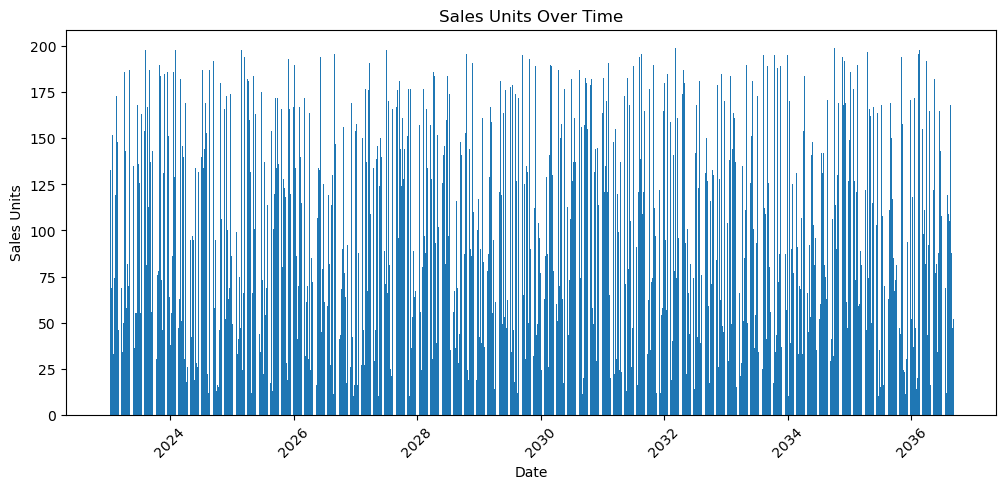

In [24]:
plt.figure(figsize=(12, 5))

plt.bar(df['date'], df['sales_units'])

plt.title("Sales Units Over Time")
plt.xlabel("Date")
plt.ylabel("Sales Units")

plt.xticks(rotation=45)
plt.show()

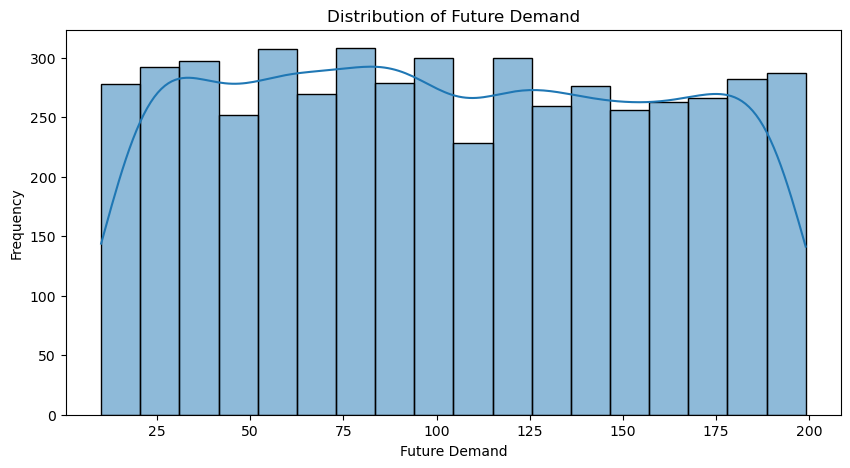

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(df['future_demand'], kde=True)

plt.title("Distribution of Future Demand")
plt.xlabel("Future Demand")
plt.ylabel("Frequency")

plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4999 non-null   datetime64[ns]
 1   product_id              4999 non-null   int64         
 2   sales_units             4999 non-null   int64         
 3   holiday_season          4999 non-null   int64         
 4   promotion_applied       4999 non-null   int64         
 5   competitor_price_index  4999 non-null   int64         
 6   economic_index          4999 non-null   int64         
 7   weather_impact          4999 non-null   int64         
 8   price                   4999 non-null   int64         
 9   discount_percentage     4999 non-null   int64         
 10  sales_revenue           4999 non-null   int64         
 11  region_Europe           4999 non-null   bool          
 12  region_North America    4999 non-null   bool    

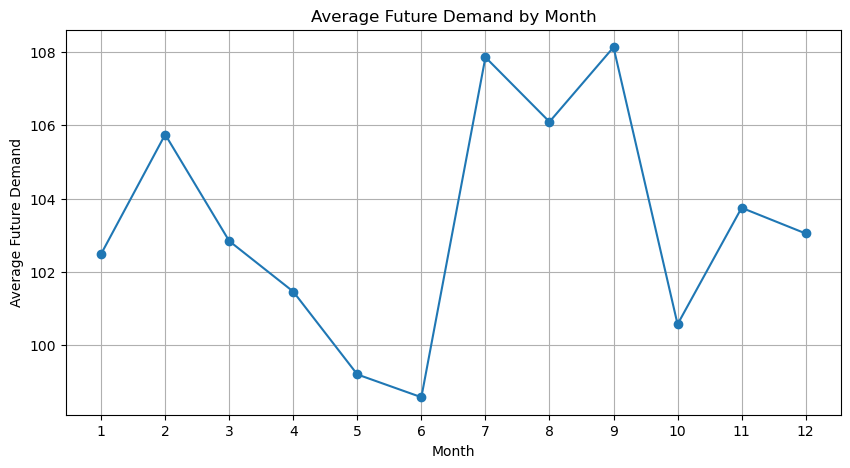

In [27]:
df['month'] = df['date'].dt.month

monthly_demand = df.groupby('month')['future_demand'].mean()

plt.figure(figsize=(10, 5))

plt.plot(monthly_demand.index, monthly_demand.values, marker='o')

plt.title("Average Future Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Future Demand")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

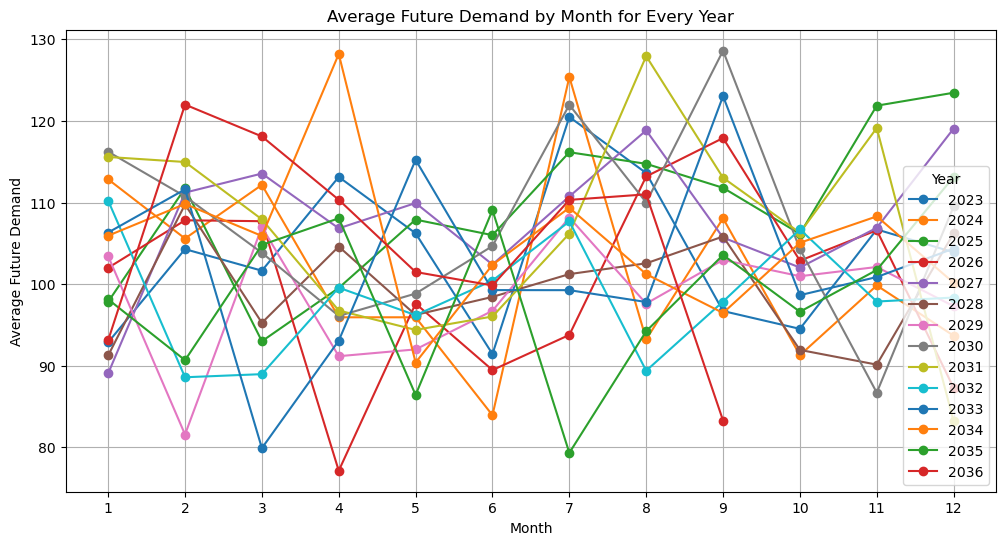

In [28]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

monthly_demand = df.groupby(
    ['year', 'month']
)['future_demand'].mean().reset_index()

plt.figure(figsize=(12, 6))

for year in monthly_demand['year'].unique():
    data = monthly_demand[monthly_demand['year'] == year]
    
    plt.plot(
        data['month'],
        data['future_demand'],
        marker='o',
        label=str(year)
    )

plt.title("Average Future Demand by Month for Every Year")
plt.xlabel("Month")
plt.ylabel("Average Future Demand")

plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True)

plt.show()

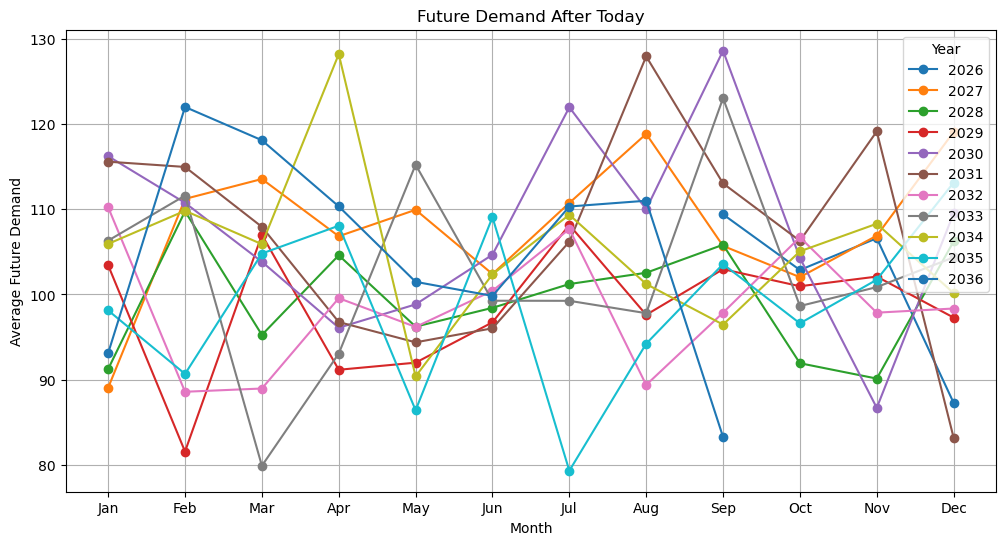

In [29]:
df['date'] = pd.to_datetime(df['date'])

today = pd.Timestamp.today().normalize()

future_df = df[df['date'] > today].copy()

future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month

monthly_demand = future_df.groupby(
    ['year', 'month']
)['future_demand'].mean().reset_index()

plt.figure(figsize=(12, 6))

for year in monthly_demand['year'].unique():
    data = monthly_demand[monthly_demand['year'] == year]

    plt.plot(
        data['month'],
        data['future_demand'],
        marker='o',
        label=str(year)
    )

plt.title("Future Demand After Today")
plt.xlabel("Month")
plt.ylabel("Average Future Demand")

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.legend(title="Year")
plt.grid(True)
plt.show()

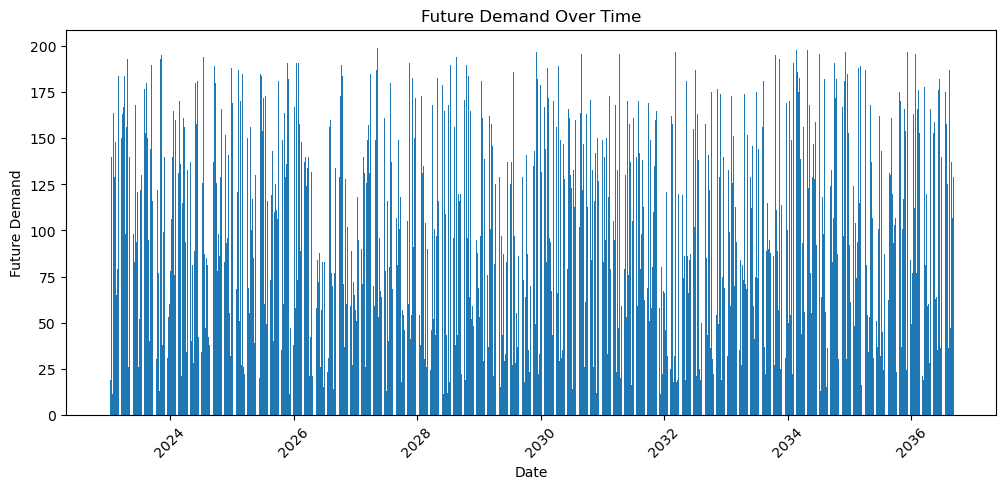

In [30]:
plt.figure(figsize=(12, 5))

plt.bar(df['date'], df['future_demand'])

plt.title("Future Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Future Demand")

plt.xticks(rotation=45)
plt.show()

<Axes: >

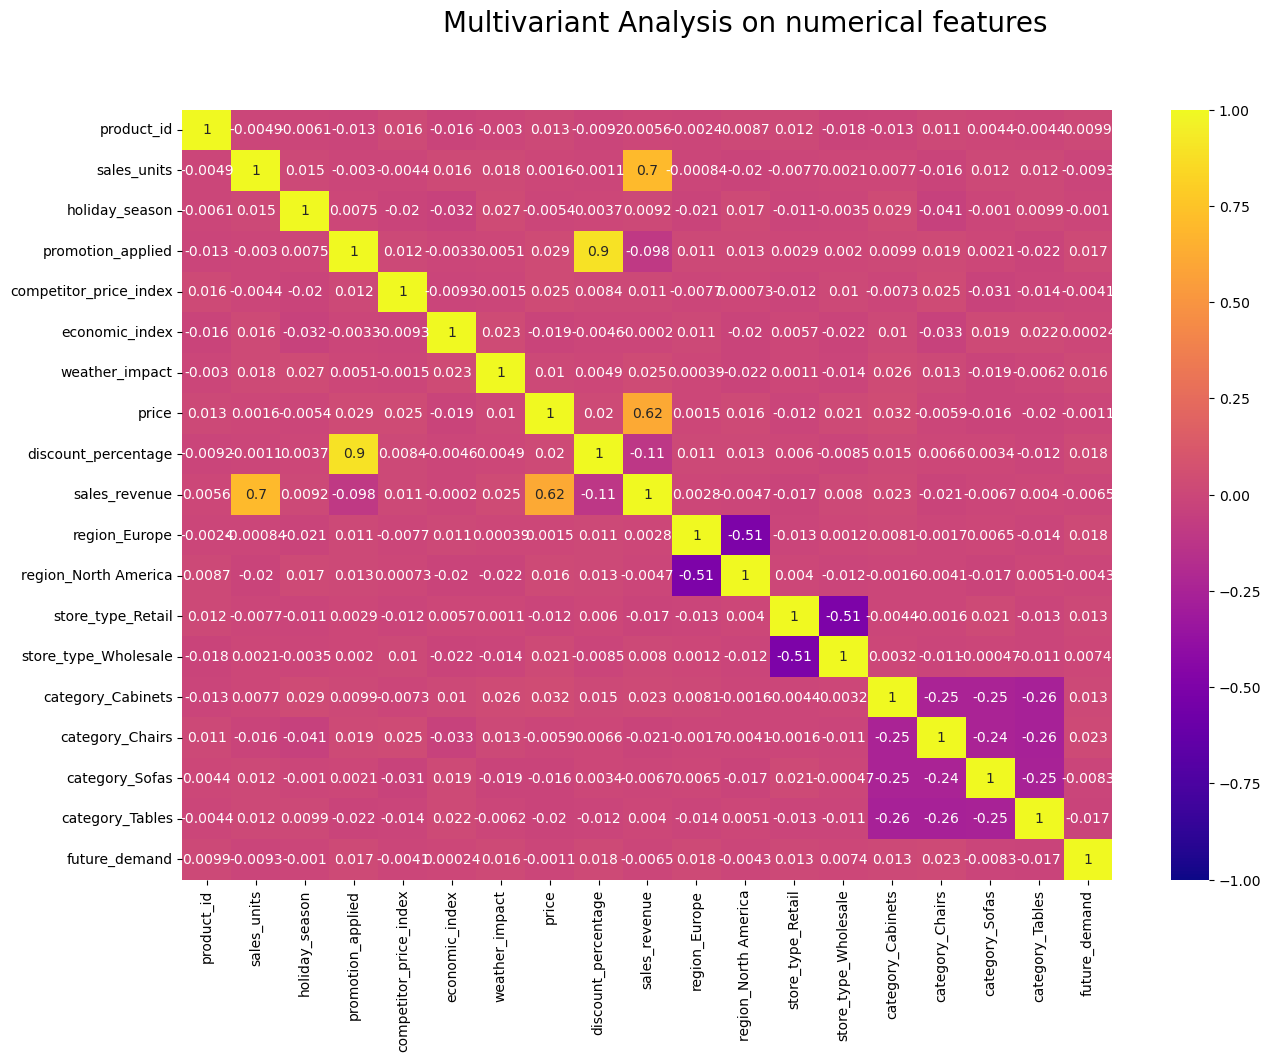

In [31]:
plt.figure(figsize=(15,10))
plt.suptitle("Multivariant Analysis on numerical features", fontsize=20)

sns.heatmap(df[numerical_features].corr(), annot=True, cmap='plasma', vmin=-1, vmax=+1)

In [32]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

In [33]:
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

In [34]:
df = df.sort_values('date')

In [35]:
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,...,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand,month,year,day,day_of_week,week_of_year
0,2023-01-01,151,99,0,0,0,1,0,126,0,...,False,True,False,False,95,1,2023,1,6,52
1,2023-01-02,192,95,1,0,0,1,0,151,0,...,True,False,False,False,101,1,2023,2,0,1
2,2023-01-03,114,101,0,0,0,1,0,191,0,...,True,False,False,False,33,1,2023,3,1,1
3,2023-01-04,171,33,0,0,1,0,0,173,0,...,False,True,False,False,82,1,2023,4,2,1
4,2023-01-05,160,82,0,1,0,1,0,138,10,...,False,False,True,False,13,1,2023,5,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,2036-09-03,135,145,0,0,1,1,0,71,0,...,False,False,True,False,30,9,2036,3,2,36
4995,2036-09-04,148,30,1,0,0,0,0,156,0,...,False,True,False,False,65,9,2036,4,3,36
4996,2036-09-05,157,65,0,0,1,0,1,122,0,...,True,False,False,False,55,9,2036,5,4,36
4997,2036-09-06,138,55,0,0,0,1,0,59,0,...,False,False,True,False,52,9,2036,6,5,36


In [36]:
#df = df.reset_index(drop=True)

In [37]:
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,...,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand,month,year,day,day_of_week,week_of_year
0,2023-01-01,151,99,0,0,0,1,0,126,0,...,False,True,False,False,95,1,2023,1,6,52
1,2023-01-02,192,95,1,0,0,1,0,151,0,...,True,False,False,False,101,1,2023,2,0,1
2,2023-01-03,114,101,0,0,0,1,0,191,0,...,True,False,False,False,33,1,2023,3,1,1
3,2023-01-04,171,33,0,0,1,0,0,173,0,...,False,True,False,False,82,1,2023,4,2,1
4,2023-01-05,160,82,0,1,0,1,0,138,10,...,False,False,True,False,13,1,2023,5,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,2036-09-03,135,145,0,0,1,1,0,71,0,...,False,False,True,False,30,9,2036,3,2,36
4995,2036-09-04,148,30,1,0,0,0,0,156,0,...,False,True,False,False,65,9,2036,4,3,36
4996,2036-09-05,157,65,0,0,1,0,1,122,0,...,True,False,False,False,55,9,2036,5,4,36
4997,2036-09-06,138,55,0,0,0,1,0,59,0,...,False,False,True,False,52,9,2036,6,5,36


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4999 non-null   datetime64[ns]
 1   product_id              4999 non-null   int64         
 2   sales_units             4999 non-null   int64         
 3   holiday_season          4999 non-null   int64         
 4   promotion_applied       4999 non-null   int64         
 5   competitor_price_index  4999 non-null   int64         
 6   economic_index          4999 non-null   int64         
 7   weather_impact          4999 non-null   int64         
 8   price                   4999 non-null   int64         
 9   discount_percentage     4999 non-null   int64         
 10  sales_revenue           4999 non-null   int64         
 11  region_Europe           4999 non-null   bool          
 12  region_North America    4999 non-null   bool    

In [39]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4999 non-null   datetime64[ns]
 1   product_id              4999 non-null   int64         
 2   sales_units             4999 non-null   int64         
 3   holiday_season          4999 non-null   int64         
 4   promotion_applied       4999 non-null   int64         
 5   competitor_price_index  4999 non-null   int64         
 6   economic_index          4999 non-null   int64         
 7   weather_impact          4999 non-null   int64         
 8   price                   4999 non-null   int64         
 9   discount_percentage     4999 non-null   int64         
 10  sales_revenue           4999 non-null   int64         
 11  region_Europe           4999 non-null   int64         
 12  region_North America    4999 non-null   int64   

In [41]:
features = [
    'sales_units',
    'holiday_season',
    'promotion_applied',
    'competitor_price_index',
    'economic_index',
    'weather_impact',
    'price',
    'discount_percentage',
    'region_Europe',
    'region_North America',
    'store_type_Retail',
    'store_type_Wholesale',
    'category_Cabinets',
    'category_Chairs',
    'category_Sofas',
    'category_Tables',
    'year',
    'month',
    'day',
    'day_of_week',
    'week_of_year'
]



In [42]:
X = df[features]
y = df['future_demand']

In [43]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
import sys
!{sys.executable} -m pip install xgboost

In [46]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score

In [47]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
linear_pred = linear_model.predict(X_test_scaled)

In [49]:
mae = mean_absolute_error(y_test, linear_pred)
mae


46.87441127373945

In [50]:
rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

print("RMSE:", rmse)

RMSE: 54.71593774557263


In [51]:
r2 = r2_score(y_test, linear_pred)

print("R2:", r2)

R2: -0.021264550825189632


In [52]:
dt = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

dt.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [53]:
y_pred_dt = dt.predict(X_test)

In [54]:
y_pred_dt

array([ 96.54025424,  84.16788321,  96.30139721, 103.89515331,
        96.30139721, 103.89515331, 103.89515331, 102.31487889,
       112.06764706, 103.89515331, 116.22972973, 121.08571429,
       103.89515331, 112.06764706, 103.89515331, 102.31487889,
        84.16788321,  96.54025424, 103.89515331,  96.30139721,
       108.5026178 ,  96.54025424,  84.16788321, 103.89515331,
       103.89515331,  96.54025424, 118.95238095,  84.16788321,
       112.06764706,  96.54025424, 132.25      , 112.06764706,
        84.16788321, 112.06764706,  96.54025424, 108.96969697,
       102.31487889, 103.89515331, 108.96969697,  96.30139721,
       103.89515331,  96.30139721,  84.16788321, 112.06764706,
       103.89515331, 102.31487889, 103.89515331, 102.31487889,
        96.30139721, 103.89515331,  29.57142857, 103.89515331,
        96.54025424, 103.89515331,  84.375     , 103.89515331,
       108.5026178 , 103.89515331, 103.89515331,  68.75      ,
       118.95238095,  96.54025424, 119.77272727, 146.75

In [55]:
mae_dt= mean_squared_error(y_test, y_pred_dt)
rmae_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf_pred = rf_model.predict(X_test)
rf_pred

array([ 96.27666667,  75.06333333, 113.45      , 106.19      ,
       109.50333333,  91.1       ,  95.37666667,  98.41      ,
       110.43666667,  96.63666667,  93.29333333,  94.61666667,
       108.78333333, 101.78      , 106.32333333, 114.98666667,
       101.09333333, 106.61666667,  98.76666667,  95.25333333,
       103.27      ,  93.71      , 113.81666667,  98.67333333,
        85.01666667,  92.74666667, 110.75333333, 100.66      ,
       107.09333333, 103.24      , 111.05333333,  97.27333333,
        79.63333333, 114.22666667,  98.17333333,  99.73666667,
       107.40333333, 100.32333333,  87.52666667, 118.42666667,
       113.61666667, 103.66333333, 100.88666667,  94.95666667,
       104.23      , 109.28333333, 111.37      , 111.44333333,
       105.96333333, 100.73666667,  81.71333333, 101.98      ,
       110.54333333,  95.20666667, 110.85666667,  96.16      ,
        96.20666667, 118.97666667, 121.72333333, 101.73666667,
       101.25666667, 111.51      , 112.09666667, 109.67

In [58]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 47.095099999999995
RMSE: 54.89953468149292
R2: -0.02812966639506498


In [59]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [60]:
xgb_pred = xgb_model.predict(X_test)

In [61]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost
MAE: 49.1763916015625
RMSE: 57.83888333795225
R2: -0.14117002487182617


In [62]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae,
        
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        rmse,
        
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        r2,
        
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,46.874411,54.715938,-0.021265
1,Random Forest,47.095100,54.899535,-0.028130
2,XGBoost,49.176392,57.838883,-0.141170


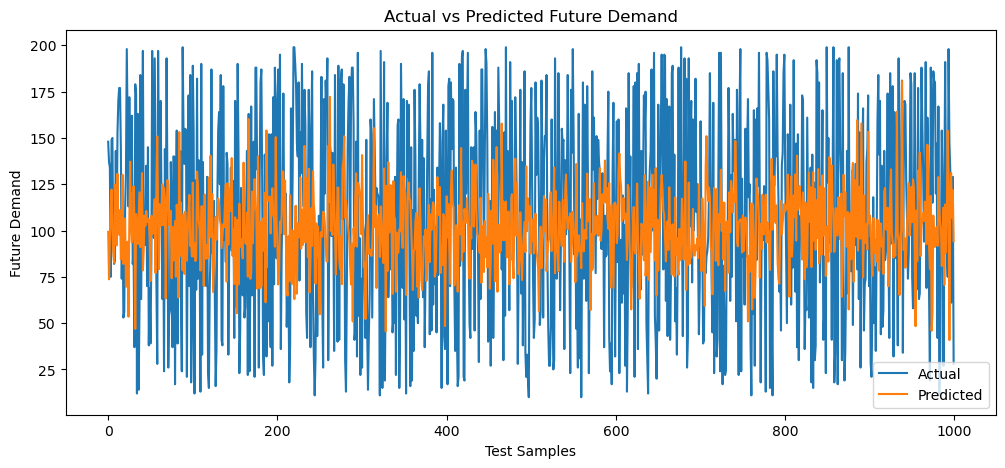

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    xgb_pred,
    label='Predicted'
)


plt.title("Actual vs Predicted Future Demand")

plt.xlabel("Test Samples")
plt.ylabel("Future Demand")

plt.legend()

plt.show()

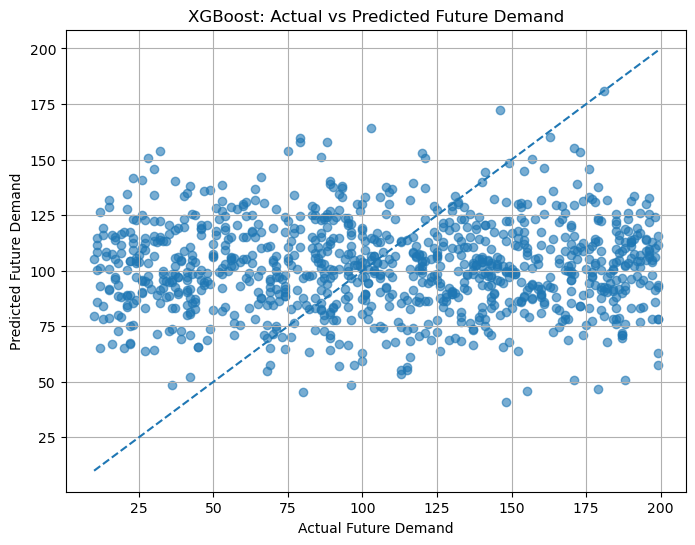

In [64]:
y_pred_xgb = xgb_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("XGBoost: Actual vs Predicted Future Demand")
plt.xlabel("Actual Future Demand")
plt.ylabel("Predicted Future Demand")

plt.grid(True)
plt.show()

In [65]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
)

importance = importance.sort_values(
    ascending=True
)

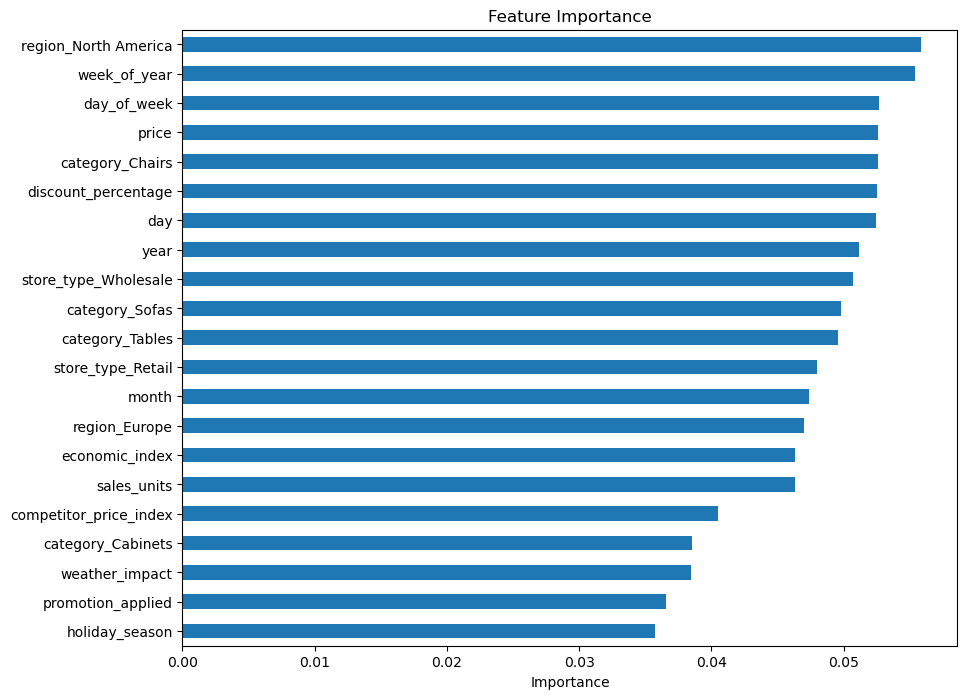

In [66]:
plt.figure(figsize=(10, 8))

importance.plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

In [67]:
import joblib

In [68]:
joblib.dump(
    xgb_model,"demand_forecasting_model.pkl"
)

['demand_forecasting_model.pkl']

In [69]:
joblib.dump(
    features,"eatures.pkl"
)

['eatures.pkl']

In [70]:
def predict_demand(input_data):

    model = joblib.load(
        "demand_forecasting_model.pkl"
    )

    prediction = model.predict(input_data)

    return prediction[0]
    